In [ ]:
# ============================================
# ZENDS Communications
# Model Training — Google Colab
# ============================================

# Install required libraries
!pip install transformers datasets scikit-learn torch accelerate -q

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [ ]:
# ============================================
# Mount Google Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folder in drive
os.makedirs('/content/drive/MyDrive/ZENDS_Copilot/models',
            exist_ok=True)
os.makedirs('/content/drive/MyDrive/ZENDS_Copilot/data',
            exist_ok=True)

print("✅ Google Drive mounted!")
print("✅ Folders created!")

Mounted at /content/drive
✅ Google Drive mounted!
✅ Folders created!


In [ ]:
# ============================================
# Load & Prepare Dataset
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/content/ZenDS_Communications_queries.csv')

print("✅ Dataset loaded!")
print(f"✅ Shape: {df.shape}")
print(f"\n📊 Intent Distribution:\n{df['intent'].value_counts()}")
print(f"\n📊 Sentiment Distribution:\n{df['sentiment'].value_counts()}")

# ============================================
# Label Encoding
# ============================================

# Intent labels
intent_encoder = LabelEncoder()
df['intent_label'] = intent_encoder.fit_transform(df['intent'])

# Sentiment labels
sentiment_encoder = LabelEncoder()
df['sentiment_label'] = sentiment_encoder.fit_transform(df['sentiment'])

print(f"\n✅ Intent Classes: {list(intent_encoder.classes_)}")
print(f"✅ Intent Labels: {list(range(len(intent_encoder.classes_)))}")
print(f"\n✅ Sentiment Classes: {list(sentiment_encoder.classes_)}")
print(f"✅ Sentiment Labels: {list(range(len(sentiment_encoder.classes_)))}")

# ============================================
# Train/Test Split
# ============================================

# Intent split
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    df['text'].values,
    df['intent_label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['intent_label'].values
)

# Sentiment split
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    df['text'].values,
    df['sentiment_label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment_label'].values
)

print(f"\n✅ Intent Train size: {len(X_train_int)}")
print(f"✅ Intent Test size: {len(X_test_int)}")
print(f"\n✅ Sentiment Train size: {len(X_train_sent)}")
print(f"✅ Sentiment Test size: {len(X_test_sent)}")

# Save encoders for later use
import pickle
with open('/content/drive/MyDrive/ZENDS_Copilot/models/intent_encoder.pkl', 'wb') as f:
    pickle.dump(intent_encoder, f)
with open('/content/drive/MyDrive/ZENDS_Copilot/models/sentiment_encoder.pkl', 'wb') as f:
    pickle.dump(sentiment_encoder, f)

print("\n✅ Encoders saved to Google Drive!")

✅ Dataset loaded!
✅ Shape: (19995, 3)

📊 Intent Distribution:
intent
Technical          3999
Refund             3999
Product Inquiry    3999
Billing            3999
Complaint          3999
Name: count, dtype: int64

📊 Sentiment Distribution:
sentiment
Happy      6665
Angry      6665
Neutral    6665
Name: count, dtype: int64

✅ Intent Classes: ['Billing', 'Complaint', 'Product Inquiry', 'Refund', 'Technical']
✅ Intent Labels: [0, 1, 2, 3, 4]

✅ Sentiment Classes: ['Angry', 'Happy', 'Neutral']
✅ Sentiment Labels: [0, 1, 2]

✅ Intent Train size: 15996
✅ Intent Test size: 3999

✅ Sentiment Train size: 15996
✅ Sentiment Test size: 3999

✅ Encoders saved to Google Drive!


In [ ]:
# ============================================
# Intent Classification Model
# DistilBERT Fine-tuning
# ============================================

import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# ============================================
# Custom Dataset Class
# ============================================

class ZENDSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ============================================
# Load Tokenizer & Model
# ============================================

print("\n🔄 Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print("🔄 Loading DistilBERT model...")
intent_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5  # 5 intent classes
)

# ============================================
# Create Datasets
# ============================================

train_dataset = ZENDSDataset(
    X_train_int, y_train_int, tokenizer)
test_dataset = ZENDSDataset(
    X_test_int, y_test_int, tokenizer)

print(f"\n✅ Train dataset: {len(train_dataset)} samples")
print(f"✅ Test dataset: {len(test_dataset)} samples")

# ============================================
# Training Arguments
# ============================================

training_args = TrainingArguments(
    output_dir='/content/intent_model_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='/content/logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'
)

# ============================================
# Metrics Function
# ============================================

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1': f1
    }

# ============================================
# Trainer
# ============================================

trainer = Trainer(
    model=intent_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# ============================================
# Train!
# ============================================

print("\n🚀 Starting Intent Model Training...")
print("⏳ This will take 15-20 minutes on T4 GPU...")
trainer.train()

print("\n✅ Intent Model Training Complete!")

✅ Device: cuda

🔄 Loading DistilBERT tokenizer...
🔄 Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Train dataset: 15996 samples
✅ Test dataset: 3999 samples


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Intent Model Training Complete!


In [ ]:
# ============================================
# Save Intent Model to Google Drive
# ============================================

print("💾 Saving Intent model to Google Drive...")

intent_model.save_pretrained(
    '/content/drive/MyDrive/ZENDS_Copilot/models/intent_model')
tokenizer.save_pretrained(
    '/content/drive/MyDrive/ZENDS_Copilot/models/intent_model')

print("✅ Intent Model saved to Google Drive!")
print("📁 Location: MyDrive/ZENDS_Copilot/models/intent_model")

💾 Saving Intent model to Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Intent Model saved to Google Drive!
📁 Location: MyDrive/ZENDS_Copilot/models/intent_model


In [ ]:
# ============================================
# Sentiment Analysis Model
# Using Pretrained HuggingFace Model
# ============================================

from transformers import pipeline
import torch

print("🔄 Loading Sentiment Model...")

# Load pretrained sentiment model
sentiment_pipeline = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=0 if torch.cuda.is_available() else -1
)

print("✅ Sentiment Model loaded!")

# ============================================
# Test Sentiment Model
# ============================================

test_texts = [
    "This is absolutely unacceptable! My bill is wrong!",
    "I would like to know about my plan details please.",
    "Hi I love ZENDS service! Keep up the great work!"
]

print("\n📊 Sentiment Model Test:")
print("=" * 50)

for text in test_texts:
    result = sentiment_pipeline(text)
    print(f"\nText: {text[:50]}...")
    print(f"Predicted: {result[0]['label']} | Score: {result[0]['score']:.4f}")

🔄 Loading Sentiment Model...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

✅ Sentiment Model loaded!

📊 Sentiment Model Test:

Text: This is absolutely unacceptable! My bill is wrong!...
Predicted: LABEL_0 | Score: 0.9765

Text: I would like to know about my plan details please....
Predicted: LABEL_1 | Score: 0.8796

Text: Hi I love ZENDS service! Keep up the great work!...
Predicted: LABEL_2 | Score: 0.9932


In [ ]:
# ============================================
# Sentiment Label Mapping
# ============================================

# cardiffnlp model labels:
# LABEL_0 = Negative = Angry
# LABEL_1 = Neutral  = Neutral
# LABEL_2 = Positive = Happy

label_mapping = {
    'LABEL_0': 'Angry',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Happy'
}

def predict_sentiment(text):
    result = sentiment_pipeline(text)
    label = result[0]['label']
    score = result[0]['score']
    mapped_label = label_mapping[label]
    return mapped_label, score

# ============================================
# Test with Mapping
# ============================================

print("📊 Sentiment Model Test — With Mapping:")
print("=" * 50)

test_texts = [
    "This is absolutely unacceptable! My bill is wrong!",
    "I would like to know about my plan details please.",
    "Hi I love ZENDS service! Keep up the great work!"
]

for text in test_texts:
    sentiment, score = predict_sentiment(text)
    print(f"\nText: {text[:50]}...")
    print(f"Sentiment: {sentiment} | Score: {score:.4f}")

# ============================================
# Evaluate on Test Dataset
# ============================================

print("\n🔄 Evaluating on test dataset...")
print("⏳ This will take a few minutes...")

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Predict on test set (use sample for speed)
sample_size = 500
X_sample = X_test_sent[:sample_size]
y_sample = y_test_sent[:sample_size]

predictions = []
for text in X_sample:
    sentiment, _ = predict_sentiment(text)
    # Convert back to label number
    pred_label = sentiment_encoder.transform([sentiment])[0]
    predictions.append(pred_label)

# Metrics
acc = accuracy_score(y_sample, predictions)
f1 = f1_score(y_sample, predictions, average='weighted')

print(f"\n✅ Sentiment Model Evaluation:")
print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"   F1 Score: {f1:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(
    y_sample, predictions,
    target_names=sentiment_encoder.classes_))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


📊 Sentiment Model Test — With Mapping:

Text: This is absolutely unacceptable! My bill is wrong!...
Sentiment: Angry | Score: 0.9765

Text: I would like to know about my plan details please....
Sentiment: Neutral | Score: 0.8796

Text: Hi I love ZENDS service! Keep up the great work!...
Sentiment: Happy | Score: 0.9932

🔄 Evaluating on test dataset...
⏳ This will take a few minutes...

✅ Sentiment Model Evaluation:
   Accuracy: 0.7440 (74.40%)
   F1 Score: 0.7268

📊 Classification Report:
              precision    recall  f1-score   support

       Angry       0.60      0.91      0.72       166
       Happy       0.95      0.95      0.95       164
     Neutral       0.78      0.39      0.52       170

    accuracy                           0.74       500
   macro avg       0.78      0.75      0.73       500
weighted avg       0.77      0.74      0.73       500



📊 Generating Confusion Matrix...


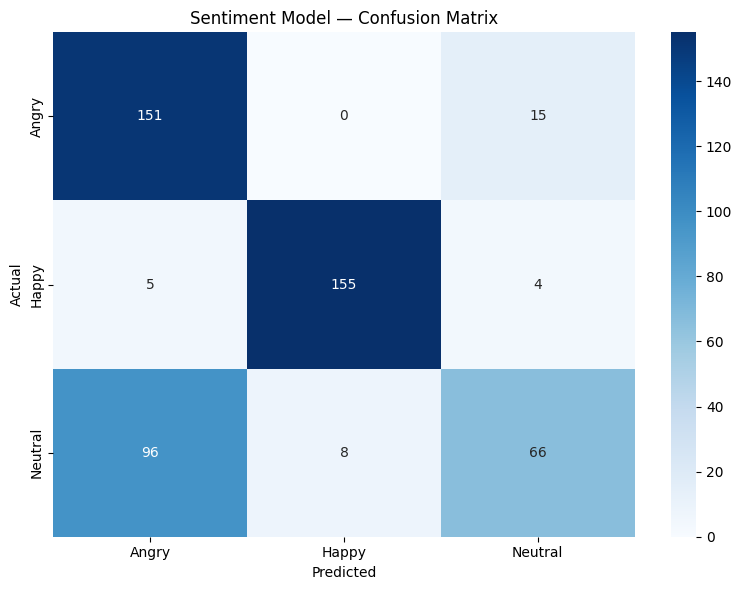

✅ Confusion Matrix saved to Google Drive!


In [ ]:
# ============================================
# Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("📊 Generating Confusion Matrix...")

cm = confusion_matrix(y_sample, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sentiment_encoder.classes_,
            yticklabels=sentiment_encoder.classes_)
plt.title('Sentiment Model — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ZENDS_Copilot/models/sentiment_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion Matrix saved to Google Drive!")

📊 Generating Intent Confusion Matrix...


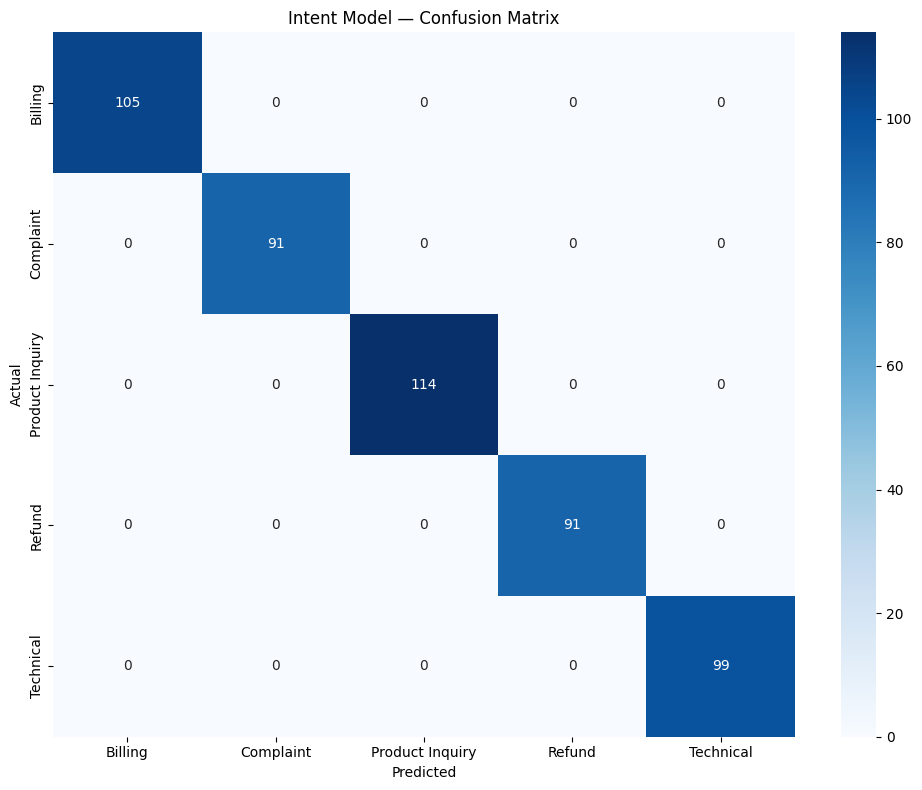


📊 Intent Classification Report:
                 precision    recall  f1-score   support

        Billing       1.00      1.00      1.00       105
      Complaint       1.00      1.00      1.00        91
Product Inquiry       1.00      1.00      1.00       114
         Refund       1.00      1.00      1.00        91
      Technical       1.00      1.00      1.00        99

       accuracy                           1.00       500
      macro avg       1.00      1.00      1.00       500
   weighted avg       1.00      1.00      1.00       500



In [ ]:
# ============================================
# Intent Model Confusion Matrix
# ============================================

print("📊 Generating Intent Confusion Matrix...")

# Predict on intent test set
intent_model.eval()
intent_model.to(device)

intent_preds = []
intent_true = []

test_dataset_eval = ZENDSDataset(
    X_test_int[:500], y_test_int[:500], tokenizer)

from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset_eval, batch_size=32)

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = intent_model(
            input_ids=input_ids,
            attention_mask=attention_mask)

        preds = outputs.logits.argmax(-1).cpu().numpy()
        intent_preds.extend(preds)
        intent_true.extend(labels.numpy())

# Confusion Matrix
cm_intent = confusion_matrix(intent_true, intent_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_intent, annot=True, fmt='d', cmap='Blues',
            xticklabels=intent_encoder.classes_,
            yticklabels=intent_encoder.classes_)
plt.title('Intent Model — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ZENDS_Copilot/models/intent_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
from sklearn.metrics import classification_report
print("\n📊 Intent Classification Report:")
print(classification_report(
    intent_true, intent_preds,
    target_names=intent_encoder.classes_))

In [ ]:
# ============================================
# Save All Models to Google Drive
# ============================================

import pickle

print("💾 Saving all models to Google Drive...")

# Save Intent Model
intent_model.save_pretrained(
    '/content/drive/MyDrive/ZENDS_Copilot/models/intent_model')
tokenizer.save_pretrained(
    '/content/drive/MyDrive/ZENDS_Copilot/models/intent_model')
print("✅ Intent model saved!")

# Save Label Encoders
with open('/content/drive/MyDrive/ZENDS_Copilot/models/intent_encoder.pkl', 'wb') as f:
    pickle.dump(intent_encoder, f)
with open('/content/drive/MyDrive/ZENDS_Copilot/models/sentiment_encoder.pkl', 'wb') as f:
    pickle.dump(sentiment_encoder, f)
print("✅ Label encoders saved!")

# Save Label Mapping
import json
with open('/content/drive/MyDrive/ZENDS_Copilot/models/sentiment_label_mapping.json', 'w') as f:
    json.dump(label_mapping, f)
print("✅ Sentiment label mapping saved!")

print("\n✅ All models saved to Google Drive!")
print("📁 Location: MyDrive/ZENDS_Copilot/models/")
print("\n📦 Files saved:")
print("   - intent_model/")
print("   - intent_encoder.pkl")
print("   - sentiment_encoder.pkl")
print("   - sentiment_label_mapping.json")
print("   - intent_confusion_matrix.png")
print("   - sentiment_confusion_matrix.png")

💾 Saving all models to Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Intent model saved!
✅ Label encoders saved!
✅ Sentiment label mapping saved!

✅ All models saved to Google Drive!
📁 Location: MyDrive/ZENDS_Copilot/models/

📦 Files saved:
   - intent_model/
   - intent_encoder.pkl
   - sentiment_encoder.pkl
   - sentiment_label_mapping.json
   - intent_confusion_matrix.png
   - sentiment_confusion_matrix.png
